In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

import xgboost as xgb
sns.set_style("whitegrid")
print("All imports successful!")

All imports successful!


In [6]:
df = pd.read_csv('/home/aniketnerali16/new/WA_Fn-UseC_-Telco-Customer-Churn-Cleaned.csv')

df_model = df.drop(columns=['customerID'])
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

if 'Churn_num' in df_model.columns:
    df_model = df_model.drop(columns=['Churn_num'])

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

cat_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(  "Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5634, 30)
Test set: (1409, 30)


/tmp/ipykernel_23232/1024466064.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [10]:
print("NaN values per column:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print("\nTotal NaNs in X_train:", X_train.isna().sum().sum())
print("Total NaNs in X_test: ", X_test.isna().sum().sum())

# Fix NaNs by filling with median for numbers
# and 0 for encoded columns
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print("\nAfter fix:")
print("NaNs in X_train:", X_train.isna().sum().sum())
print("NaNs in X_test: ", X_test.isna().sum().sum())

NaN values per column:
TotalCharges    8
dtype: int64

Total NaNs in X_train: 8
Total NaNs in X_test:  3

After fix:
NaNs in X_train: 0
NaNs in X_test:  0


In [12]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Random Forest 

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

#XGBoost

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth = 4,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric= 'logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

print ("All three models trained")


/home/aniketnerali16/new/venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [10:32:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


All three models trained


In [14]:
def evaluate_model(name, model, X_test_input, y_test):
    y_pred = model.predict(X_test_input)
    y_prob = model.predict_proba(X_test_input)[:,1]

    return{
        'Model': name,
        'Accuaracy': round(accuracy_score(y_test, y_pred) * 100, 1),
        'AUC Score': round(roc_auc_score(y_test, y_prob),3),
        'Precision': round(float(classification_report(y_test, y_pred, output_dict=True)['1']['precision']),3),
        'Recall': round(float(classification_report(y_test, y_pred, output_dict=True)['1']['recall']),3),
        'F1 Score' : round(float(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']),3)
    }



results = pd.DataFrame([
    evaluate_model('Logistic Regression', lr,        X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf,        X_test,        y_test),
    evaluate_model('XGBoost',             xgb_model, X_test,        y_test),
])

results

,Model,Accuaracy,AUC Score,Precision,Recall,F1 Score
0,Logistic Regression,80.7,0.842,0.658,0.567,0.609
1,Random Forest,80.6,0.844,0.671,0.529,0.592
2,XGBoost,80.3,0.845,0.658,0.535,0.590


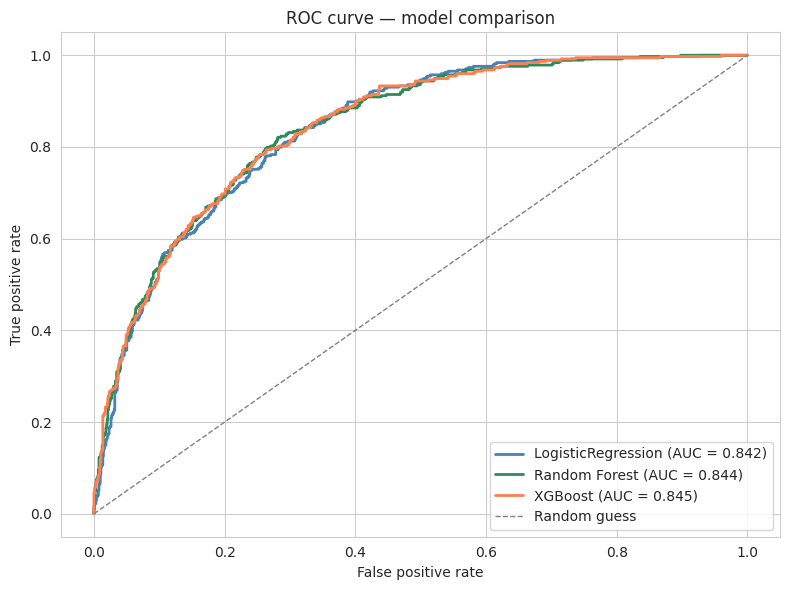

In [15]:
plt.figure(figsize=(8,6))

models = [
    ('LogisticRegression', lr,          X_test_scaled, 'steelblue'),
    ('Random Forest',      rf,          X_test,         'seagreen'),
    ('XGBoost',            xgb_model,   X_test,           'coral'),
]

for name, model, X_input, color in models :
    y_prob = model.predict_proba(X_input)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color =color, lw=2, label = f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — model comparison')
plt.legend()
plt.tight_layout()
plt.show()

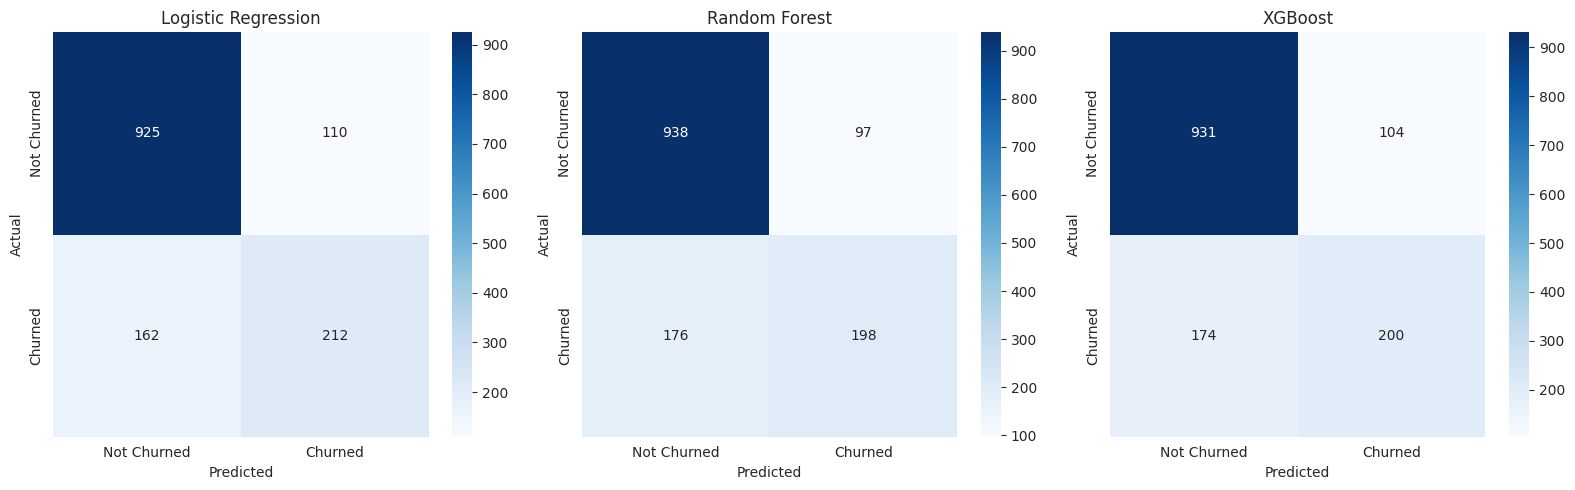

In [20]:
# Redefine models list fresh
models_list = [
    ('Logistic Regression', lr,        X_test_scaled),
    ('Random Forest',       rf,        X_test),
    ('XGBoost',             xgb_model, X_test),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, model, X_input) in enumerate(models_list):
    y_pred = model.predict(X_input)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        ax=axes[i],
        xticklabels=['Not Churned', 'Churned'],
        yticklabels=['Not Churned', 'Churned']
    )
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


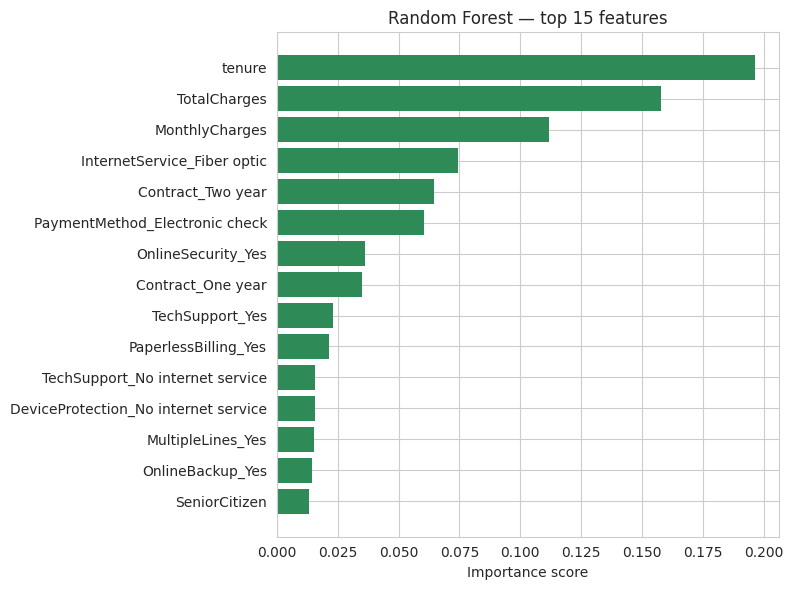

In [21]:
rf_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], 
         color='seagreen', edgecolor='none')
plt.xlabel('Importance score')
plt.title('Random Forest — top 15 features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

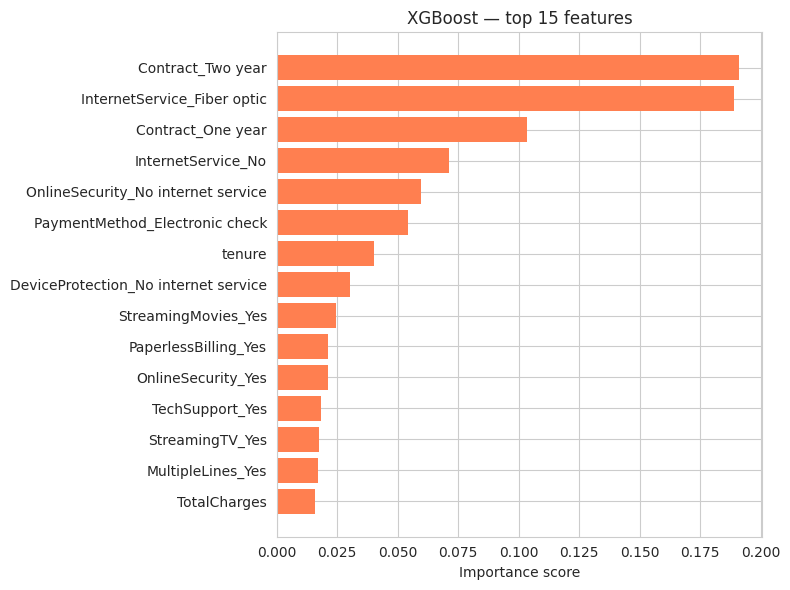

In [22]:
xgb_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'],
         color='coral', edgecolor='none')
plt.xlabel('Importance score')
plt.title('XGBoost — top 15 features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

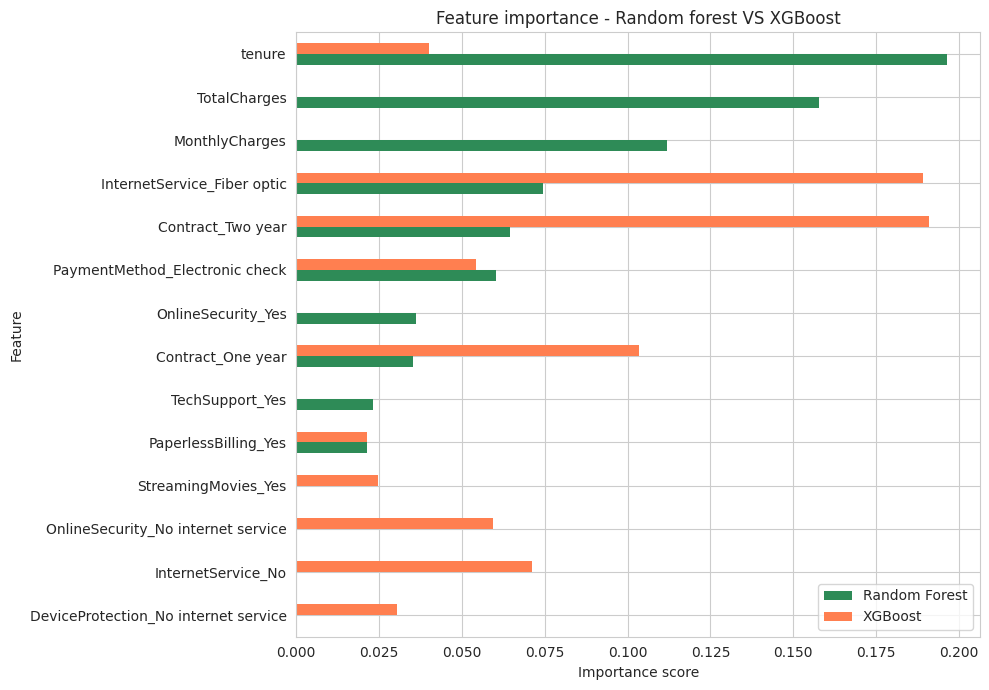

In [23]:
top_rf = rf_importance.head(10).set_index('Feature')['Importance']
top_xgb = xgb_importance.head(10).set_index('Feature')['Importance']

# Combine and Sort

combined = pd.DataFrame({'Random Forest': top_rf, 'XGBoost': top_xgb}).fillna(0)
combined = combined.sort_values('Random Forest', ascending = True)

combined.plot(kind='barh', figsize=(10,7), color=['seagreen', 'coral'], edgecolor='none')
plt.title('Feature importance - Random forest VS XGBoost')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

In [26]:
df_results = pd.read_csv('/home/aniketnerali16/new/WA_Fn-UseC_-Telco-Customer-Churn-Cleaned.csv')

df_export = df_results.drop(columns=['customerID', 'Churn'])
if 'Churn_num' in df_export.columns:
    df_export = df_export.drop(columns=['Churn_num'])


cat_cols = df_export.select_dtypes(include='object').columns
df_exports = pd.get_dummies(df_export, columns =cat_cols, drop_first=True)
df_export = df_export.reindex(columns=X.columns, fill_value=0)


df_results['Churn_Probability'] = xgb_model.predict_proba(df_export)[:,1].round(3)
df_results['Churn_Predicted'] = xgb_model.predict(df_export)
df_results['Risk_Segment']  = pd.cut(
    df_results['Churn_Probability'],
    bins=[0,0.3, 0.6, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

df_results.to_csv('/home/aniketnerali16/new/WA_Fn-UseC_-Telco-Customer-Churn-Predictions.csv', index=False)

print(f"Exported {len(df_results)} rows!")
print("\nRisk segment breakdown:")
print(df_results['Risk_Segment'].value_counts())
print("\nSample output:")
df_results[['customerID', 'Churn', 'Churn_Probability', 'Risk_Segment']].head()

/tmp/ipykernel_23232/24316282.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_export.select_dtypes(include='object').columns


Exported 7043 rows!

Risk segment breakdown:
Risk_Segment
Low risk       5487
Medium risk    1397
High risk       159
Name: count, dtype: int64

Sample output:


,customerID,Churn,Churn_Probability,Risk_Segment
0,7590-VHVEG,No,0.477,Medium risk
1,5575-GNVDE,No,0.111,Low risk
2,3668-QPYBK,Yes,0.503,Medium risk
3,7795-CFOCW,No,0.120,Low risk
4,9237-HQITU,Yes,0.413,Medium risk
